# Camera → BEV segmentation — training

Stage 1: surround cameras → BEV drivable-area + vehicle segmentation, metric BEV mIoU.

This notebook's first block is **data loading**: build the train/val datasets over
nuScenes keyframes, each carrying the 6 camera images, raw per-sensor calibration,
and the precomputed BEV raster target. It stops at the `DataLoader` boundary — the
`collate_fn` (variable per-sample sensor/agent batching + masking) and the
`DataLoader` setup are written separately.

In [1]:
%load_ext autoreload
%autoreload 2

from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import torch

REPO_ROOT = Path.cwd()
SRC = REPO_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from bev.data import CAMERAS, NuScenesBEVDataset, NuScenesConfig, Sample

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"torch {torch.__version__}  device={device}")

torch 2.9.1+cu129  device=cuda


In [2]:
# Paths and grid/target configuration.
DATAROOT = REPO_ROOT / "data" / "nuscenes"
VERSION = "v1.0-mini"
RASTER_ROOT = REPO_ROOT / "data" / "bev_rasters"

# Stage 1 is camera-only: all 6 cameras in, lidar off. The BEV target comes from
# the precomputed raster store, so annotations are not loaded at train time.
SPLITS = {"train": "mini_train", "val": "mini_val"}

In [3]:
def build_dataset(split: str) -> NuScenesBEVDataset:
    return NuScenesBEVDataset(
        NuScenesConfig(
            dataroot=DATAROOT,
            version=VERSION,
            split=split,
            cameras=CAMERAS,
            load_lidar=False,
            load_annotations=False,
            bev_raster_root=RASTER_ROOT / split,
        )
    )


train_set = build_dataset(SPLITS["train"])
val_set = build_dataset(SPLITS["val"])
print(f"train: {len(train_set)} keyframes   val: {len(val_set)} keyframes")

train: 323 keyframes   val: 81 keyframes


## Sanity check one sample

Confirm each item carries what the model and loss expect: 6 camera tensors, raw
calibration per camera, and a `(C, H, W)` BEV raster whose layers and grid match
the store. The per-layer occupied fraction is a quick read on the BEV class
imbalance the loss has to handle.

In [4]:
sample: Sample = train_set[0]

print(f"sample_token: {sample.sample_token}")
print(f"scene:        {sample.scene_name}")
print(f"cameras:      {list(sample.cameras)}")

cam = sample.cameras[CAMERAS[0]]
print(f"\n{cam.channel}: image {tuple(cam.image.shape)} {cam.image.dtype}")
print(f"  intrinsic:\n{cam.calib.intrinsic}")
print(f"  sensor2ego t: {cam.calib.sensor2ego_translation.tolist()}")
print(f"  ego2global t: {cam.calib.ego2global_translation.tolist()}")

raster = sample.bev_raster
assert raster is not None, "bev_raster_root not wired or sample missing a raster"
data = raster.data  # (C, H, W)
print(f"\nraster: {tuple(data.shape)} {data.dtype}  layers={raster.layer_names}")
print(f"  grid: {raster.spec.nx}x{raster.spec.ny} @ {raster.spec.resolution} m")
for c, name in enumerate(raster.layer_names):
    frac = float((data[c] > 0).float().mean())
    print(f"  {name:14s} occupied {frac:6.3%}")

sample_token: cd9964f8c3d34383b16e9c2997de1ed0
scene:        scene-0757
cameras:      ['CAM_FRONT_LEFT', 'CAM_FRONT', 'CAM_FRONT_RIGHT', 'CAM_BACK_LEFT', 'CAM_BACK', 'CAM_BACK_RIGHT']

CAM_FRONT_LEFT: image (3, 900, 1600) torch.uint8
  intrinsic:
tensor([[1.2579e+03, 0.0000e+00, 8.2724e+02],
        [0.0000e+00, 1.2579e+03, 4.5092e+02],
        [0.0000e+00, 0.0000e+00, 1.0000e+00]], dtype=torch.float64)
  sensor2ego t: [1.5752559464, 0.500519383135, 1.50696032589]
  ego2global t: [334.7712219122368, 658.6383442168495, 0.0]

raster: (2, 200, 200) torch.float32  layers=('drivable_area', 'vehicle')
  grid: 200x200 @ 0.5 m
  drivable_area  occupied 19.905%
  vehicle        occupied 1.250%


## DataLoaders

In [7]:
from torch.utils.data import DataLoader

from bev.data import collate_fn

TRAIN_BATCH_SIZE = 1
VAL_BATCH_SIZE = 1


train_loader = DataLoader(train_set, batch_size=TRAIN_BATCH_SIZE, shuffle=True, collate_fn=collate_fn, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=VAL_BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=4, pin_memory=True)

In [8]:
import matplotlib.pyplot as plt

# test loader
train_sample = next(iter(train_loader))
print(train_sample)

SampleBatch(camera_batch=CameraDataBatch(channels=('CAM_FRONT_LEFT', 'CAM_FRONT', 'CAM_FRONT_RIGHT', 'CAM_BACK_LEFT', 'CAM_BACK', 'CAM_BACK_RIGHT'), images=tensor([[[[[-7.8871e-01, -7.4607e-01, -7.2657e-01,  ...,  1.7889e+00,
             1.7718e+00,  1.7606e+00],
           [-7.4824e-01, -7.4096e-01, -7.4539e-01,  ...,  1.7790e+00,
             1.7619e+00,  1.7498e+00],
           [-7.2559e-01, -7.4781e-01, -7.6217e-01,  ...,  1.7890e+00,
             1.7719e+00,  1.7624e+00],
           ...,
           [-1.7510e+00, -1.7401e+00, -1.7377e+00,  ..., -4.8383e-01,
            -4.7974e-01, -4.9270e-01],
           [-1.7661e+00, -1.7707e+00, -1.7519e+00,  ..., -5.0241e-01,
            -4.8810e-01, -4.7041e-01],
           [-1.8082e+00, -1.8422e+00, -1.8192e+00,  ..., -4.9965e-01,
            -4.8189e-01, -4.5719e-01]],

          [[-6.0683e-01, -5.6323e-01, -5.4330e-01,  ...,  2.2034e+00,
             2.1859e+00,  2.1745e+00],
           [-5.6545e-01, -5.5800e-01, -5.6254e-01,  ...,  2.193

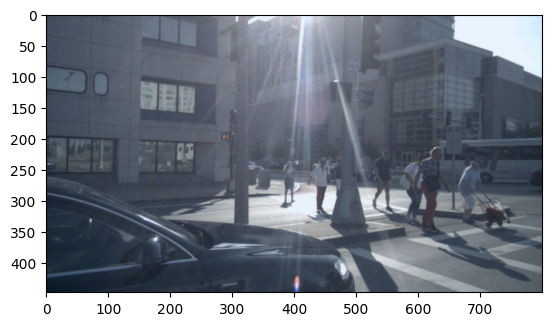

In [9]:
plt.imshow((train_sample.camera_batch.images[0,0].permute(1,2,0)-train_sample.camera_batch.images[0,0].min())/(train_sample.camera_batch.images[0,0].max()-train_sample.camera_batch.images[0,0].min()))

## Training

### ResNet inspection

In [ ]:
# import torch
# from torch import nn

# from torchvision.models import (
#     resnet18,
#     resnet34,
#     resnet50,
#     ResNet18_Weights,
#     ResNet34_Weights,
#     ResNet50_Weights,
# )

In [ ]:
# resnet = resnet18(weights=None)
# print(resnet)
# for name, child in resnet.named_children():
#     print(name, ":", child)
# for name, module in resnet.named_modules():
#     print(name, ":", module)
# for param_name, param_tensor in resnet.named_parameters():
#     print(param_name, ":", param_tensor.shape)
# for name, child in resnet.layer1[0].named_children():
#     print(name, ":", child)
# for name, parameter in resnet.layer1[0].conv1.named_parameters():
#     print(name, ":", parameter)
# print(resnet.layer1[0].conv1.weight.data)
# print(resnet.state_dict())
# print(ResNet18_Weights.IMAGENET1K_V1.transforms())

### Model creation & training

In [10]:
from bev.models import CameraBEVSeg, CameraBEVSegScatter

MIN_HEIGHT = -0.5
MAX_HEIGHT = 3.0
NUM_HEIGHTS = 4
MIN_DEPTH = 0
MAX_DEPTH = 42
NUM_DEPTHS = 42

import gc
# free any previous model/optimizer before rebuilding
for _name in ("camera_bev_seg", "opt"):
    if _name in globals():
        del globals()[_name]
gc.collect()
torch.cuda.empty_cache()

camera_bev_seg = CameraBEVSeg(train_set[0].bev_raster.spec, train_set[0].bev_raster.layer_names, MIN_HEIGHT, MAX_HEIGHT, NUM_HEIGHTS, MIN_DEPTH, MAX_DEPTH, NUM_DEPTHS)
# camera_bev_seg = CameraBEVSegScatter(train_set[0].bev_raster.spec, train_set[0].bev_raster.layer_names, MIN_DEPTH, MAX_DEPTH, NUM_DEPTHS)

# if warm-start or just loading the model
# state = torch.load("models/frozen-warmup/camera_bev_seg_best.pt", map_location=device, weights_only=True)
# camera_bev_seg.load_state_dict(state)

camera_bev_seg.to(device)

/home/pliampas/PROJECTS/bev-perception/.venv/lib/python3.12/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4317.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


CameraBEVSeg(
  (bevlift): BEVLift(
    (backbone): ResNetBackbone(
      (resnet): ResNet(
        (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
        (layer1): Sequential(
          (0): BasicBlock(
            (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (relu): ReLU(inplace=True)
            (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          )
          (1): BasicBlock(
            (conv1): Conv2d(64, 64, kernel_size=(3, 3), str

In [14]:
import gc
from bev.data.nuscenes_dataset import SampleBatch
from bev.models import SegLoss
from bev.viz.predictions import plot_train_val_predictions

GAMMA = 2
ALPHAS = (0.25, 0.5)
EPS = 1e-5
LAMBDA = 1

seg_loss = SegLoss(GAMMA, ALPHAS, EPS, LAMBDA).to(device)

opt = torch.optim.Adam(camera_bev_seg.parameters(), lr=1e-4, betas=(0.9, 0.999), eps=1e-8, weight_decay=1e-12)

# resnet_ids = {id(p) for p in camera_bev_seg.bevlift.backbone.resnet.parameters()}
# backbone_params = [p for p in camera_bev_seg.parameters() if id(p) in resnet_ids and p.requires_grad]
# new_params      = [p for p in camera_bev_seg.parameters() if id(p) not in resnet_ids and p.requires_grad]

# opt = torch.optim.Adam(
#     [
#         {"params": backbone_params, "lr": 1e-5},   # pretrained → gentle
#         {"params": new_params,      "lr": 1e-4},   # from scratch → faster
#     ],
#     weight_decay=1e-4,
# )

# fixed sets of 5 train + 5 val frames, sampled once, to watch the same frames improve
viz_train_batch = collate_fn([train_set[i] for i in range(5)])
viz_train_batch.to(device)
viz_val_batch = collate_fn([val_set[i] for i in range(5)])
viz_val_batch.to(device)

NUM_EPOCHS = 15
MAX_PATIENCE = 5

prev_total_loss = -1
patience_cnt = 0

# clear GPU before training (release remnants from prior runs)
gc.collect()
torch.cuda.empty_cache()

for epoch in range(NUM_EPOCHS):
    print(f"Starting epoch {epoch}")

    camera_bev_seg.train()

    total_train_loss = 0

    sample: SampleBatch
    for sample in train_loader:
        input = sample.camera_batch.to(device)
        target = sample.bev_raster_batch.data.to(device)
        opt.zero_grad()
        logits = camera_bev_seg(input)
        loss = seg_loss(logits, target)
        total_train_loss += loss.item()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(camera_bev_seg.parameters(), 1.0)
        opt.step()
    
    print(f"Epoch {epoch} training loss: {total_train_loss}")
    
    camera_bev_seg.eval()
    total_val_loss = 0

    with torch.no_grad():
        for sample in val_loader:
            input = sample.camera_batch.to(device)
            target = sample.bev_raster_batch.data.to(device)
            logits = camera_bev_seg(input)
            loss = seg_loss(logits, target)
            total_val_loss += loss.item()
    
    print(f"Epoch {epoch} val loss: {total_val_loss}")

    del sample, input, target, logits, loss
    gc.collect()
    torch.cuda.empty_cache()

    plot_train_val_predictions(
        camera_bev_seg,
        viz_train_batch.camera_batch, viz_train_batch.bev_raster_batch.data,
        viz_val_batch.camera_batch, viz_val_batch.bev_raster_batch.data,
        viz_val_batch.bev_raster_batch.layer_names, n=5,
        save_path=f"viz/epoch_{epoch}.png", title=f"epoch {epoch}  (train | val)",
    )

    torch.save(camera_bev_seg.state_dict(), f"models/camera_bev_seg_{epoch}.pt")

    if prev_total_loss == -1 or total_val_loss < prev_total_loss:
        torch.save(camera_bev_seg.state_dict(), f"models/camera_bev_seg_best.pt")
        prev_total_loss = total_val_loss
        patience_cnt = 0
    else:
        patience_cnt += 1
    
    if patience_cnt >= MAX_PATIENCE:
        print(f"Early stopping at epoch {epoch}")
        break

Starting epoch 0
Epoch 0 training loss: 218.30522203445435
Epoch 0 val loss: 67.43054574728012
Starting epoch 1
Epoch 1 training loss: 210.85257560014725
Epoch 1 val loss: 64.89481818675995
Starting epoch 2
Epoch 2 training loss: 202.77248519659042
Epoch 2 val loss: 65.03683984279633
Starting epoch 3
Epoch 3 training loss: 193.5706223845482
Epoch 3 val loss: 63.334484934806824
Starting epoch 4
Epoch 4 training loss: 183.4935167133808
Epoch 4 val loss: 63.95110732316971
Starting epoch 5
Epoch 5 training loss: 173.94456085562706
Epoch 5 val loss: 61.34619462490082
Starting epoch 6
Epoch 6 training loss: 167.2669258415699
Epoch 6 val loss: 66.95443212985992
Starting epoch 7
Epoch 7 training loss: 161.09959253668785
Epoch 7 val loss: 65.13858437538147
Starting epoch 8
Epoch 8 training loss: 156.70107853412628
Epoch 8 val loss: 67.18755728006363
Starting epoch 9
Epoch 9 training loss: 152.74789947271347
Epoch 9 val loss: 67.67503219842911
Starting epoch 10
Epoch 10 training loss: 149.552599